In [2]:
import pandas as pd
import numpy as np

In [10]:
df["presvote20post"].value_counts()

presvote20post
Joe Biden                     589
Donald Trump                  349
Did not vote for President     26
Jo Jorgensen                   15
Howie Hawkins                   6
Other                           4
Name: count, dtype: int64

In [3]:
df = pd.read_csv("master_data_2020.csv")
df = df[~df["presvote20post"].isna()]

# ==========================================
# 1. DEFINE SOURCE COLUMNS
# ==========================================
treatment = "untrustworthy_flag"
raw_vote_choice_col = "presvote20post"

# ==========================================
# 2. OVERWRITE & CLEAN TARGET OUTCOMES FROM TEXT
# ==========================================
# Ensure we capture text responses and handle any trailing whitespaces cleanly
vote_series = df[raw_vote_choice_col].astype(str).str.strip()

# 1. Fix Biden Vote (1 if explicitly voted for Biden, 0 otherwise)
df["voted_biden_2020"] = np.where(vote_series == "Joe Biden", 1, 0)

# 2. Fix Trump Vote (1 if explicitly voted for Trump, 0 otherwise)
df["voted_trump_2020"] = np.where(vote_series == "Donald Trump", 1, 0)

# 3. Create Turnout (0 if they didn't vote or skipped, 1 if they cast a ballot)
# Based on your data, non-voters show up as "Did not vote for President" or missing strings
df["turnout_2020_binary"] = np.where(
    vote_series.str.contains("did not vote|skipped|__na__", case=False, na=True),
    0,
    1
)

# Structure our clean target dictionary for the loop
outcomes = {
    "2020 Turnout": "turnout_2020_binary",
    "Voted for Biden": "voted_biden_2020",
    "Voted for Trump": "voted_trump_2020",
}

# ==========================================
# 3. COMPREHENSIVE FEATURE ENGINEERING (CONDENSED & STREAMLINED)
# ==========================================
# Process Digital Literacy Index
tf_cols = ["tf_adv", "tf_pdf", "tf_spy", "tf_wiki", "tf_cache", "tf_phishing"]
df_tf = df[tf_cols].map(
    lambda val: int(str(val).strip().split()[0])
    if pd.notna(val) and str(val).strip().split()[0].isdigit()
    else np.nan
)
df["digital_literacy_index"] = df_tf.mean(axis=1)

# Linearized Political Mappings
df["ideo5_linear"] = df["ideo5"].map({"Very liberal": 1, "Liberal": 2, "Moderate": 3, "Conservative": 4, "Very conservative": 5})
df["pid7_linear"] = df["pid7"].map({"Strong Democrat": 1, "Not very strong Democrat": 2, "Lean Democrat": 3, "Independent": 4, "Lean Republican": 5, "Not very strong Republican": 6, "Strong Republican": 7})

# Linearized Social Media Scale
socmed_mapping = {
    "Less than 10 minutes per day": 1, "10–30 minutes per day": 2, "31–60 minutes per day": 3,
    "1–2 hours per day": 4, "2–3 hours per day": 5, "More than 3 hours per day": 6
}
df["socmed_use_linear"] = df["socmed_use"].astype(str).str.strip().map(socmed_mapping)

# --- NEW: Condense News Interest into a Linear Scale ---
newsint_mapping = {
    "Hardly at all": 1,
    "Only now and then": 2,
    "Some of the time": 3,
    "Most of the time": 4
}
df["newsint_linear"] = df["newsint"].astype(str).str.strip().map(newsint_mapping)

# --- NEW: Condense Internet Use Frequency into a Linear Scale ---
intuse_mapping = {
    "Less often": 1,
    "About once a day": 3,
    "Several times a day": 4,
    "A few times a week": 2  # Catching common top-tier survey labels if present
}
# Fallback to handle "Several times a day" as the top option if "Almost constantly" isn't used
df["intuse_linear"] = df["intuse"].astype(str).str.strip().map(intuse_mapping).fillna(3)

# --- NEW: Condense 2016 Vote into Trump, Clinton, and Other ---
# Modified 2016 vote processing function
def condense_2016_vote_fixed(val):
    val_str = str(val).strip()
    if val_str in ["Hillary Clinton", "Donald Trump"]:
        return val_str
    # Explicitly group non-voters and missing responses into a valid category string
    elif pd.isna(val) or val_str in ["__NA__", "nan", "Did not vote", "Did not vote for President"]:
        return "Did Not Vote"
    else:
        return "Other"

df["presvote16post_condensed"] = df["presvote16post"].apply(condense_2016_vote_fixed)

# REMOVE 'turnout16' from your categorical_covariates list!
# 'presvote16post_condensed' now handles turnout implicitly.
categorical_covariates = [
    "race4", 
    "educ4", 
    "region", 
    "presvote16post_condensed" # Will generate dummies for Clinton, Other, and Did Not Vote. 
]
# Gather all our dense numeric/linear features
linear_features = [
    "ideo5_linear", 
    "pid7_linear", 
    "socmed_use_linear", 
    "newsint_linear", 
    "intuse_linear"
]

# ==========================================
# 4. DESIGN MATRIX GENERATION (THE COVARIATES)
# ==========================================
core_cols = [treatment] + list(outcomes.values()) + ["age", "female"]
engineered_continuous = ["digital_literacy_index"]


# Clean complete-case alignment
all_processed_cols = core_cols + engineered_continuous + linear_features + categorical_covariates
df_clean = df[all_processed_cols].dropna().copy()

# Build the final compact X Matrix
# 1. Generate all dummies with drop_first=False so we can manually control the baselines
X_matrix = pd.get_dummies(
    df_clean[["age", "female"] + engineered_continuous + linear_features + categorical_covariates],
    columns=categorical_covariates,
    drop_first=False,
    dtype=int,
)

# 2. Define exactly one baseline reference column to drop from each categorical group
baselines_to_drop = [
    'presvote16post_condensed_Donald Trump',  # 2016 Vote baseline
    'race4_White',                            # Race baseline
    'educ4_College grad',                     # Education baseline
    'region_Midwest',                         # Region baseline
]

# 3. Drop them safely from the matrix
X_matrix = X_matrix.drop(columns=baselines_to_drop, errors='ignore')

# ==========================================
# 5. FINAL AIPW INPUT EXTRACTION
# ==========================================
W = df_clean[treatment].astype(int).values
Y_turnout = df_clean[outcomes["2020 Turnout"]].astype(int).values
Y_biden = df_clean[outcomes["Voted for Biden"]].astype(int).values
Y_trump = df_clean[outcomes["Voted for Trump"]].astype(int).values

print("--- PIPELINE VERIFICATION ---")
print(f"Total valid sample size (N): {len(df_clean)}")
print(f"Total covariates in X_matrix: {X_matrix.shape[1]}")
print(f"Mean 2020 Turnout rate: {Y_turnout.mean():.2%}")
print(f"Mean unconditional Biden support: {Y_biden.mean():.2%}")
print(f"Mean unconditional Trump support: {Y_trump.mean():.2%}")

--- PIPELINE VERIFICATION ---
Total valid sample size (N): 956
Total covariates in X_matrix: 20
Mean 2020 Turnout rate: 97.38%
Mean unconditional Biden support: 59.73%
Mean unconditional Trump support: 35.46%


In [4]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm

# 1. statsmodels requires an explicit intercept column
X_with_constant = sm.add_constant(X_matrix)

# Pack outcomes into a dictionary matching our extracted variables
outcome_data = {
    "Voted for Biden": Y_biden,
    "Voted for Trump": Y_trump
}

print("--- RUNNING LOGISTIC AIPW ESTIMATION (STATSMODELS) ---")

for name, Y in outcome_data.items():
    try:
        # ----------------------------------------------------
        # STEP 1: Propensity Score Model e(X) via pure MLE
        # ----------------------------------------------------
        prop_model = sm.Logit(W, X_with_constant).fit(disp=0, maxiter=1000)
        e_hat = prop_model.predict(X_with_constant)
        
        # Clip propensity scores to protect against extreme weights
        e_hat = np.clip(e_hat, 0.05, 0.95)
        
        # ----------------------------------------------------
        # STEP 2: Outcome Models mu_1(X) and mu_0(X)
        # ----------------------------------------------------
        # Fit model only on the treated units (W == 1)
        out_model_1 = sm.Logit(Y[W == 1], X_with_constant.iloc[W == 1]).fit(disp=0, maxiter=1000)
        mu_1_hat = out_model_1.predict(X_with_constant)
        
        # Fit model only on the control units (W == 0)
        out_model_0 = sm.Logit(Y[W == 0], X_with_constant.iloc[W == 0]).fit(disp=0, maxiter=1000)
        mu_0_hat = out_model_0.predict(X_with_constant)
        
        # ----------------------------------------------------
        # STEP 3: Compute AIPW Scores & Asymptotic Variance
        # ----------------------------------------------------
        N = len(Y)
        
        base_diff = mu_1_hat - mu_0_hat
        treated_correction = (W * (Y - mu_1_hat)) / e_hat
        control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)
        
        # Generate final point-level scores
        aipw_scores = base_diff + treated_correction - control_correction
        
        # Unbiased Average Treatment Effect (ATE)
        ate = np.mean(aipw_scores)
        
        # Analytical standard errors derived from the empirical influence curve
        influence_curve = aipw_scores - ate
        variance = np.var(influence_curve, ddof=1) / N
        std_error = np.sqrt(variance)
        
        # Compute Wald Z-Test statistics
        z_stat = ate / std_error
        p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
        
        # Confidence Intervals (95%)
        ci_lower = ate - (1.96 * std_error)
        ci_upper = ate + (1.96 * std_error)
        
        # ----------------------------------------------------
        # STEP 4: Print Clean Estimates
        # ----------------------------------------------------
        print(f"\nOutcome: {name}")
        print(f"  ATE: {ate:+.4f} ({ate*100:+.2f} percentage points)")
        print(f"  Std Error: {std_error:.4f}")
        print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
        print(f"  p-value:   {p_val:.4f}")
        
    except Exception as e:
        print(f"\nModel for '{name}' failed to converge or encountered an error:")
        print(f"  Error details: {e}")

--- RUNNING LOGISTIC AIPW ESTIMATION (STATSMODELS) ---

Outcome: Voted for Biden
  ATE: -0.0286 (-2.86 percentage points)
  Std Error: 0.0149
  95% CI:   [-0.0578, +0.0006]
  p-value:   0.0547

Outcome: Voted for Trump
  ATE: +0.0144 (+1.44 percentage points)
  Std Error: 0.0147
  95% CI:   [-0.0144, +0.0432]
  p-value:   0.3279


In [5]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.ensemble import RandomForestClassifier

# Use our clean master X_matrix values
X = X_matrix.values
N = len(W)

candidate_outcomes = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}

# Native NumPy K-Fold generation
np.random.seed(42)
indices = np.arange(N)
np.random.shuffle(indices)

num_folds = 5
folds = np.array_split(indices, num_folds)

print("--- RUNNING LIGHTWEIGHT RANDOM FOREST AIPW ---")

for name, Y in candidate_outcomes.items():
    # Placeholders for out-of-fold probability predictions
    e_hat = np.zeros(N)
    mu_1_hat = np.zeros(N)
    mu_0_hat = np.zeros(N)

    for f in range(num_folds):
        val_idx = folds[f]
        train_idx = np.setdiff1d(indices, val_idx)

        X_train, X_val = X[train_idx], X[val_idx]
        W_train, W_val = W[train_idx], W[val_idx]
        Y_train, Y_val = Y[train_idx], Y[val_idx]

        # ----------------------------------------------------
        # STEP 1: Lightweight Propensity Score Model e(X)
        # ----------------------------------------------------
        # Max depth = 2 prevents hyper-partisans from getting 0.99 or 0.01 propensities
        prop_model = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        prop_model.fit(X_train, W_train)
        e_hat[val_idx] = prop_model.predict_proba(X_val)[:, 1]

        # ----------------------------------------------------
        # STEP 2: Lightweight Outcome Models mu_1(X) and mu_0(X)
        # ----------------------------------------------------
        treated_mask = W_train == 1
        out_model_1 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_1.fit(X_train[treated_mask], Y_train[treated_mask])
        mu_1_hat[val_idx] = out_model_1.predict_proba(X_val)[:, 1]

        control_mask = W_train == 0
        out_model_0 = RandomForestClassifier(
            n_estimators=100, 
            max_depth=10, 
            min_samples_leaf=10,
            random_state=42, 
            n_jobs=-1
        )
        out_model_0.fit(X_train[control_mask], Y_train[control_mask])
        mu_0_hat[val_idx] = out_model_0.predict_proba(X_val)[:, 1]

    # ----------------------------------------------------
    # STEP 3: Symmetric Trimming & AIPW Core Math
    # ----------------------------------------------------
    e_hat = np.clip(e_hat, 0.05, 0.95)

    base_diff = mu_1_hat - mu_0_hat
    treated_correction = (W * (Y - mu_1_hat)) / e_hat
    control_correction = ((1 - W) * (Y - mu_0_hat)) / (1 - e_hat)

    aipw_scores = base_diff + treated_correction - control_correction
    ate = np.mean(aipw_scores)

    # Asymptotic Standard Errors via Influence Curve
    influence_curve = aipw_scores - ate
    variance = np.var(influence_curve, ddof=1) / N
    std_error = np.sqrt(variance)

    # Inference Math
    z_stat = ate / std_error
    p_val = 2 * (1 - stats.norm.cdf(np.abs(z_stat)))
    ci_lower = ate - (1.96 * std_error)
    ci_upper = ate + (1.96 * std_error)

    print(f"\nOutcome: {name}")
    print(f"  ATE: {ate:+.4f} ({ate*100:+.2f} percentage points)")
    print(f"  Std Error: {std_error:.4f}")
    print(f"  95% CI:   [{ci_lower:+.4f}, {ci_upper:+.4f}]")
    print(f"  p-value:   {p_val:.4f}")

--- RUNNING LIGHTWEIGHT RANDOM FOREST AIPW ---

Outcome: Voted for Biden
  ATE: -0.0462 (-4.62 percentage points)
  Std Error: 0.0194
  95% CI:   [-0.0843, -0.0081]
  p-value:   0.0175

Outcome: Voted for Trump
  ATE: +0.0469 (+4.69 percentage points)
  Std Error: 0.0192
  95% CI:   [+0.0093, +0.0846]
  p-value:   0.0146


Fitting RF cross-fold models... done.

=== OVERLAP / COMMON SUPPORT DIAGNOSTIC ===
N=956  |  Treated=311  |  Control=645

Unclipped RF propensity scores:
  Full:     [0.0709, 0.7074]  mean=0.3290
  Treated:  [0.1115, 0.7074]  mean=0.3799
  Control:  [0.0709, 0.6711]  mean=0.3044

Tail mass at common trim thresholds:
  e(X) < 0.05:   0 (0.0%)   | e(X) > 0.95:   0 (0.0%)
  e(X) < 0.10:   6 (0.6%)   | e(X) > 0.90:   0 (0.0%)
  e(X) < 0.20: 128 (13.4%)   | e(X) > 0.80:   0 (0.0%)

IPW Effective Sample Size (Kish 1965):
  Treated ESS: 268  (raw n=311)
  Control ESS: 621  (raw n=645)
  Combined ESS/N: 93.0%


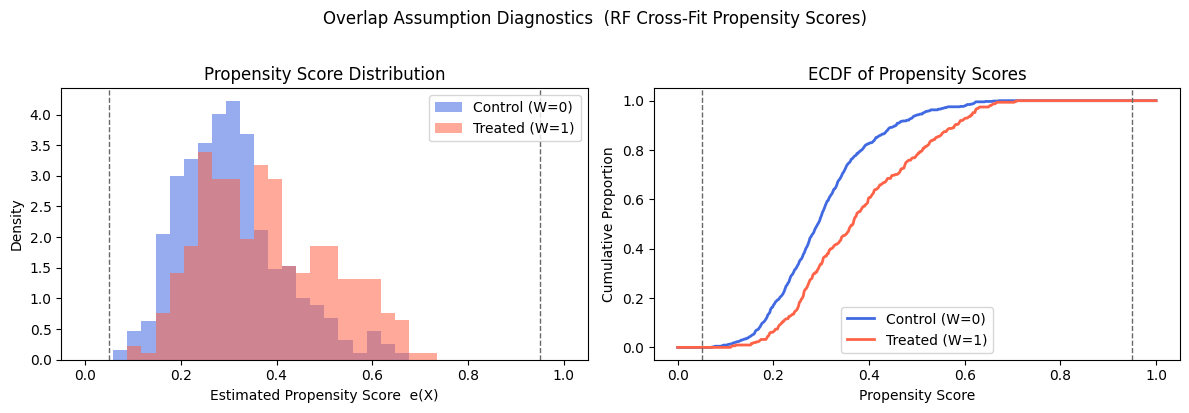

In [6]:
# ====================================================
# OVERLAP / COMMON SUPPORT CHECK  (RF Cross-Fit)
# ====================================================
# Re-runs the 5-fold RF cross-fitting from the cell above,
# storing all out-of-fold predictions for the sensitivity
# analysis below. Diagnostics use the unclipped scores.

from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF
import numpy as np

X  = X_matrix.values
N  = len(W)
outcome_arrs = {"Voted for Biden": Y_biden, "Voted for Trump": Y_trump}

np.random.seed(42)
idx = np.arange(N)
np.random.shuffle(idx)
folds = np.array_split(idx, 5)

e_hat_rf = np.zeros(N)
mu_1_rf  = {name: np.zeros(N) for name in outcome_arrs}
mu_0_rf  = {name: np.zeros(N) for name in outcome_arrs}

rf_kw = dict(n_estimators=100, max_depth=10, min_samples_leaf=10, random_state=42, n_jobs=-1)

print("Fitting RF cross-fold models...", end=" ", flush=True)
for f in range(5):
    val_idx   = folds[f]
    train_idx = np.setdiff1d(idx, val_idx)
    X_tr, X_val = X[train_idx], X[val_idx]
    W_tr        = W[train_idx]

    e_hat_rf[val_idx] = (
        RandomForestClassifier(**rf_kw).fit(X_tr, W_tr).predict_proba(X_val)[:, 1]
    )

    for name, Y_full in outcome_arrs.items():
        Y_tr = Y_full[train_idx]
        mu_1_rf[name][val_idx] = (
            RandomForestClassifier(**rf_kw)
            .fit(X_tr[W_tr == 1], Y_tr[W_tr == 1])
            .predict_proba(X_val)[:, 1]
        )
        mu_0_rf[name][val_idx] = (
            RandomForestClassifier(**rf_kw)
            .fit(X_tr[W_tr == 0], Y_tr[W_tr == 0])
            .predict_proba(X_val)[:, 1]
        )
print("done.")

# ---------------------------------------------------------
# Overlap statistics on unclipped propensity scores
# ---------------------------------------------------------
e_raw = e_hat_rf
tr, ct = W == 1, W == 0

print("\n=== OVERLAP / COMMON SUPPORT DIAGNOSTIC ===")
print(f"N={N}  |  Treated={tr.sum()}  |  Control={ct.sum()}")
print(f"\nUnclipped RF propensity scores:")
print(f"  Full:     [{e_raw.min():.4f}, {e_raw.max():.4f}]  mean={e_raw.mean():.4f}")
print(f"  Treated:  [{e_raw[tr].min():.4f}, {e_raw[tr].max():.4f}]  mean={e_raw[tr].mean():.4f}")
print(f"  Control:  [{e_raw[ct].min():.4f}, {e_raw[ct].max():.4f}]  mean={e_raw[ct].mean():.4f}")

print(f"\nTail mass at common trim thresholds:")
for alpha in [0.05, 0.10, 0.20]:
    n_lo = (e_raw < alpha).sum()
    n_hi = (e_raw > 1 - alpha).sum()
    print(f"  e(X) < {alpha:.2f}: {n_lo:>3d} ({n_lo/N:.1%})   "
          f"| e(X) > {1-alpha:.2f}: {n_hi:>3d} ({n_hi/N:.1%})")

# Kish (1965) effective sample size under IPW
ess_t = (tr / e_raw).sum()**2 / (tr / e_raw**2).sum()
ess_c = (ct / (1-e_raw)).sum()**2 / (ct / (1-e_raw)**2).sum()
print(f"\nIPW Effective Sample Size (Kish 1965):")
print(f"  Treated ESS: {ess_t:.0f}  (raw n={tr.sum()})")
print(f"  Control ESS: {ess_c:.0f}  (raw n={ct.sum()})")
print(f"  Combined ESS/N: {(ess_t + ess_c)/N:.1%}")

# ---------------------------------------------------------
# Plots: histogram and ECDF
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, 1, 35)
ax1.hist(e_raw[ct], bins=bins, alpha=0.55, color="royalblue", density=True, label="Control (W=0)")
ax1.hist(e_raw[tr], bins=bins, alpha=0.55, color="tomato",    density=True, label="Treated (W=1)")
for x in [0.05, 0.95]:
    ax1.axvline(x, color="dimgray", linestyle="--", lw=1)
ax1.set_xlabel("Estimated Propensity Score  e(X)")
ax1.set_ylabel("Density")
ax1.set_title("Propensity Score Distribution")
ax1.legend()

ps_grid = np.linspace(0, 1, 500)
ax2.plot(ps_grid, ECDF(e_raw[ct])(ps_grid), color="royalblue", lw=2, label="Control (W=0)")
ax2.plot(ps_grid, ECDF(e_raw[tr])(ps_grid), color="tomato",    lw=2, label="Treated (W=1)")
for x in [0.05, 0.95]:
    ax2.axvline(x, color="dimgray", linestyle="--", lw=1)
ax2.set_xlabel("Propensity Score")
ax2.set_ylabel("Cumulative Proportion")
ax2.set_title("ECDF of Propensity Scores")
ax2.legend()

plt.suptitle("Overlap Assumption Diagnostics  (RF Cross-Fit Propensity Scores)", y=1.02)
plt.tight_layout()
plt.show()


=== SENSITIVITY ANALYSIS (RF AIPW) ===

--- A. Trimming Sensitivity (hard trim, predictions held fixed) ---
   alpha      N   Biden ATE            Biden 95% CI   Trump ATE            Trump 95% CI
  -------------------------------------------------------------------------------------
  0.010    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]
  0.025    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]
  0.050    956    -0.0462  [-0.0843, -0.0081]    +0.0469  [+0.0093, +0.0846]  <- baseline
  0.075    955    -0.0460  [-0.0841, -0.0079]    +0.0468  [+0.0091, +0.0845]
  0.100    950    -0.0454  [-0.0837, -0.0070]    +0.0463  [+0.0084, +0.0842]
  0.150    925    -0.0471  [-0.0852, -0.0089]    +0.0457  [+0.0076, +0.0838]
  0.200    828    -0.0475  [-0.0869, -0.0082]    +0.0475  [+0.0069, +0.0880]


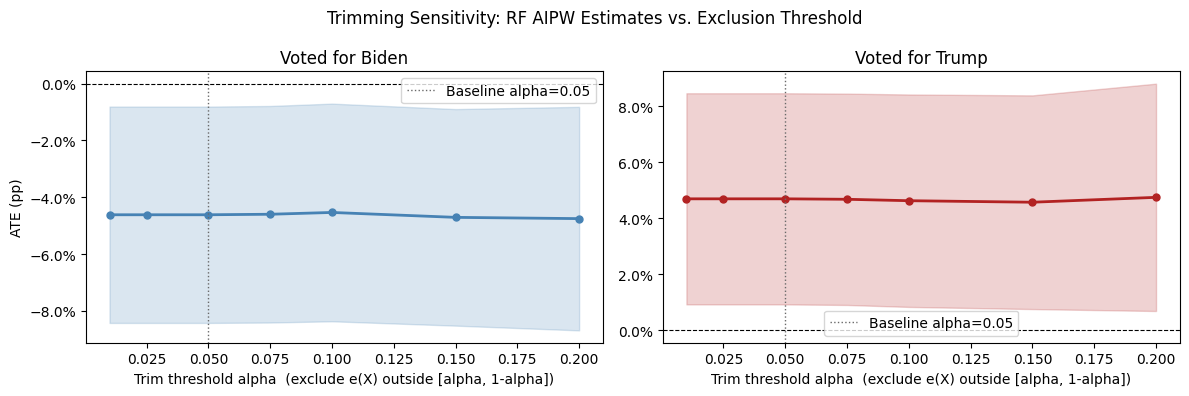


--- B. E-Values (alpha=0.05 baseline estimates) ---
  Interpretation: an unmeasured confounder with RR >= E with BOTH
  treatment and outcome is needed to fully explain away the effect.

  Outcome                   p0       ATE      RR    E(ATE)    CI bound    E(CI)
  -----------------------------------------------------------------------------
  Voted for Biden        0.671   -0.0462   1.074     1.355     -0.0081    1.123
  Voted for Trump        0.281   +0.0469   1.167     1.609     +0.0093    1.218

  Note: E(CI) is for the CI bound closest to zero.
  If the CI already crosses zero, E(CI) = 1.0 (trivially null).


In [7]:
# ====================================================
# SENSITIVITY ANALYSIS  (RF AIPW)
# ====================================================
# Uses e_hat_rf, mu_1_rf, mu_0_rf from the overlap cell.
#
# A. Trimming sensitivity  — how do RF AIPW estimates change
#    as we hard-trim units with extreme propensity scores?
# B. E-values (VanderWeele & Ding 2017) — minimum confounding
#    strength needed to explain away the observed effects.

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np

# ---------------------------------------------------------
# A. TRIMMING SENSITIVITY
# ---------------------------------------------------------
# For each threshold alpha, exclude units with e(X) outside
# [alpha, 1-alpha] and recompute AIPW on the retained sample.
# Cross-fitted predictions (mu_1_rf, mu_0_rf) are held fixed
# across thresholds -- a standard approximation for sensitivity.

alphas = [0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20]
trim_res = {name: dict(ate=[], ci_lo=[], ci_hi=[], n=[]) for name in outcome_arrs}

for alpha in alphas:
    keep = (e_hat_rf >= alpha) & (e_hat_rf <= 1 - alpha)
    e_k  = np.clip(e_hat_rf[keep], alpha, 1 - alpha)
    W_k  = W[keep]
    N_k  = keep.sum()

    for name in outcome_arrs:
        Y_k   = outcome_arrs[name][keep]
        mu1_k = mu_1_rf[name][keep]
        mu0_k = mu_0_rf[name][keep]

        psi = (mu1_k - mu0_k
               + (W_k * (Y_k - mu1_k)) / e_k
               - ((1 - W_k) * (Y_k - mu0_k)) / (1 - e_k))
        ate = psi.mean()
        se  = np.sqrt(psi.var(ddof=1) / N_k)
        trim_res[name]["ate"].append(ate)
        trim_res[name]["ci_lo"].append(ate - 1.96 * se)
        trim_res[name]["ci_hi"].append(ate + 1.96 * se)
        trim_res[name]["n"].append(N_k)

print("=== SENSITIVITY ANALYSIS (RF AIPW) ===\n")
print("--- A. Trimming Sensitivity (hard trim, predictions held fixed) ---")
hdr = (f"  {'alpha':>6}  {'N':>5}  {'Biden ATE':>10}  "
       f"{'Biden 95% CI':>22}  {'Trump ATE':>10}  {'Trump 95% CI':>22}")
print(hdr)
print("  " + "-" * (len(hdr) - 2))
for i, alpha in enumerate(alphas):
    n  = trim_res["Voted for Biden"]["n"][i]
    b, bl, bh = (trim_res["Voted for Biden"]["ate"][i],
                 trim_res["Voted for Biden"]["ci_lo"][i],
                 trim_res["Voted for Biden"]["ci_hi"][i])
    t, tl, th = (trim_res["Voted for Trump"]["ate"][i],
                 trim_res["Voted for Trump"]["ci_lo"][i],
                 trim_res["Voted for Trump"]["ci_hi"][i])
    flag = "  <- baseline" if alpha == 0.05 else ""
    print(f"  {alpha:.3f}  {n:>5}  {b:>+9.4f}  [{bl:>+.4f}, {bh:>+.4f}]"
          f"  {t:>+9.4f}  [{tl:>+.4f}, {th:>+.4f}]{flag}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette = {"Voted for Biden": "steelblue", "Voted for Trump": "firebrick"}
for ax, name in zip(axes, trim_res):
    col  = palette[name]
    ates = trim_res[name]["ate"]
    lo   = trim_res[name]["ci_lo"]
    hi   = trim_res[name]["ci_hi"]
    ax.fill_between(alphas, lo, hi, alpha=0.20, color=col)
    ax.plot(alphas, ates, "o-", color=col, lw=2, ms=5)
    ax.axhline(0, color="black", lw=0.8, linestyle="--")
    ax.axvline(0.05, color="dimgray", linestyle=":", lw=1, label="Baseline alpha=0.05")
    ax.set_xlabel("Trim threshold alpha  (exclude e(X) outside [alpha, 1-alpha])")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=1))
    ax.set_title(name)
    ax.legend()
axes[0].set_ylabel("ATE (pp)")
plt.suptitle("Trimming Sensitivity: RF AIPW Estimates vs. Exclusion Threshold")
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# B. E-VALUES  (VanderWeele & Ding 2017, Ann. Intern. Med.)
# ---------------------------------------------------------
# The E-value is the minimum risk-ratio (RR) association that
# an unmeasured binary confounder must have with BOTH treatment
# AND outcome simultaneously to fully explain away the effect.
#
# Formula (RR >= 1):  E = RR + sqrt(RR * (RR - 1))
# We convert additive ATEs to approximate RRs using the
# control-group baseline rate, then compute E for both the
# point estimate and the CI bound closest to zero.

def _evalue(rr):
    rr = max(rr, 1.0)
    return rr + np.sqrt(rr * (rr - 1))

def rr_from_rd(rd, p0):
    p1 = np.clip(p0 + rd, 1e-6, 1 - 1e-6)
    rr = p1 / p0
    return rr if rr >= 1 else 1.0 / rr

p0_vals = {name: float(outcome_arrs[name][W == 0].mean()) for name in outcome_arrs}
base_i  = alphas.index(0.05)

print("\n--- B. E-Values (alpha=0.05 baseline estimates) ---")
print("  Interpretation: an unmeasured confounder with RR >= E with BOTH")
print("  treatment and outcome is needed to fully explain away the effect.")
print()
col_hdr = (f"  {'Outcome':<22} {'p0':>5}  {'ATE':>8}  "
           f"{'RR':>6}  {'E(ATE)':>8}  {'CI bound':>10}  {'E(CI)':>7}")
print(col_hdr)
print("  " + "-" * (len(col_hdr) - 2))

for name in ["Voted for Biden", "Voted for Trump"]:
    ate      = trim_res[name]["ate"][base_i]
    ci_lo    = trim_res[name]["ci_lo"][base_i]
    ci_hi    = trim_res[name]["ci_hi"][base_i]
    p0       = p0_vals[name]
    ci_bound = ci_hi if ate < 0 else ci_lo

    rr_ate = rr_from_rd(ate, p0)
    ev_ate = _evalue(rr_ate)
    rr_ci  = rr_from_rd(ci_bound, p0)
    ev_ci  = _evalue(rr_ci) if abs(ci_bound) > 0.001 else 1.0

    print(f"  {name:<22} {p0:.3f}  {ate:>+8.4f}  {rr_ate:>6.3f}"
          f"  {ev_ate:>8.3f}  {ci_bound:>+10.4f}  {ev_ci:>7.3f}")

print()
print("  Note: E(CI) is for the CI bound closest to zero.")
print("  If the CI already crosses zero, E(CI) = 1.0 (trivially null).")
